# Exercise 1 (Solution): Visualizing KNN Decision Boundaries (Iris Dataset)

### Step 1: Load the Iris dataset and apply PCA to reduce the feature space to 2D

In [4]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

iris = load_iris()
X = PCA(n_components=2).fit_transform(iris.data)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
X_train.shape, X_test.shape

((112, 2), (38, 2))

### Step 2: Define the function to train and visualize KNN decision boundaries

In [5]:
from sklearn.neighbors import KNeighborsClassifier

def plot_knn_decision_boundary(X_train, y_train, X_test, y_test, k):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)

    xx, yy = np.meshgrid(
        np.linspace(X_train[:, 0].min()-1, X_train[:, 0].max()+1, 300),
        np.linspace(X_train[:, 1].min()-1, X_train[:, 1].max()+1, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', cmap='Set2', label='Train')
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='r', cmap='Set2', marker='x', label='Test')
    plt.title(f"K={k} | Train Acc: {clf.score(X_train, y_train):.2f} | Test Acc: {clf.score(X_test, y_test):.2f}")
    plt.legend()
    plt.show()

### Step 3: Run the function with different k values

<ipython-input-5-8d138efcb9bb>:14: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='r', cmap='Set2', marker='x', label='Test')


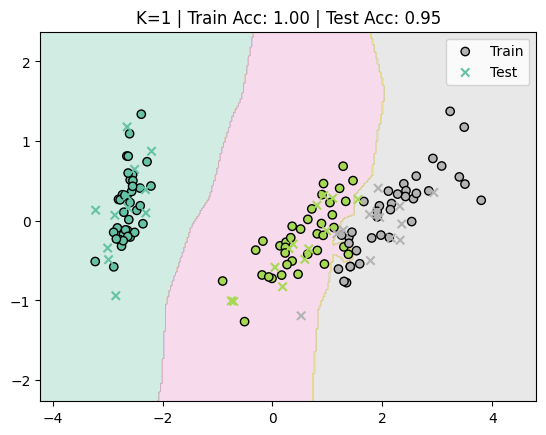

<ipython-input-5-8d138efcb9bb>:14: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='r', cmap='Set2', marker='x', label='Test')


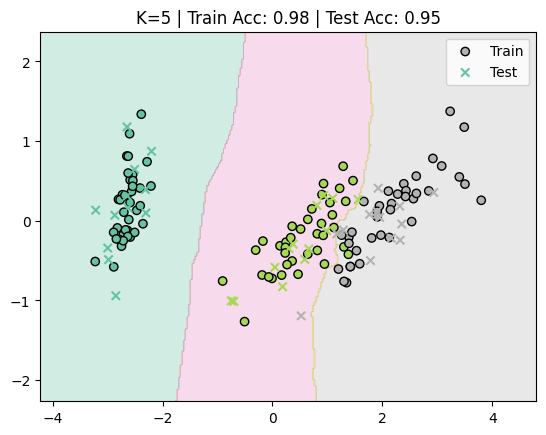

<ipython-input-5-8d138efcb9bb>:14: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='r', cmap='Set2', marker='x', label='Test')


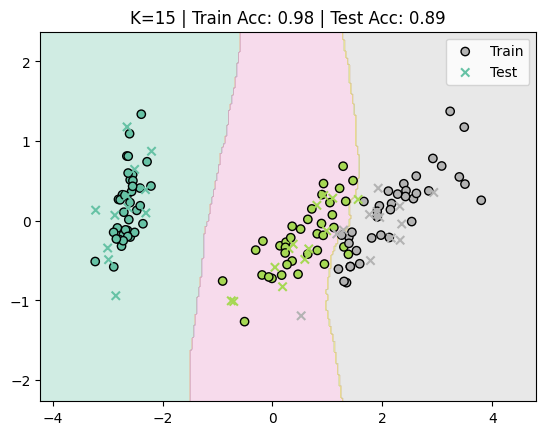

In [6]:
for k in [1, 5, 15]:
    plot_knn_decision_boundary(X_train, y_train, X_test, y_test, k)

# Exercise 2 (Solution): Random Forest vs Decision Tree Regression

### Step 1: Load the dataset and split it

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, test_size=0.3, random_state=42)
X_train.shape, X_test.shape

((14448, 8), (6192, 8))

### Step 2: Train Decision Tree and Random Forest and compute MSE

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
print(f"Decision Tree MSE: {mean_squared_error(y_test, y_pred_dt):.2f}")
print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred_rf):.2f}")

Decision Tree MSE: 0.42
Random Forest MSE: 0.26


### Step 3: Visualize predicted vs. true values

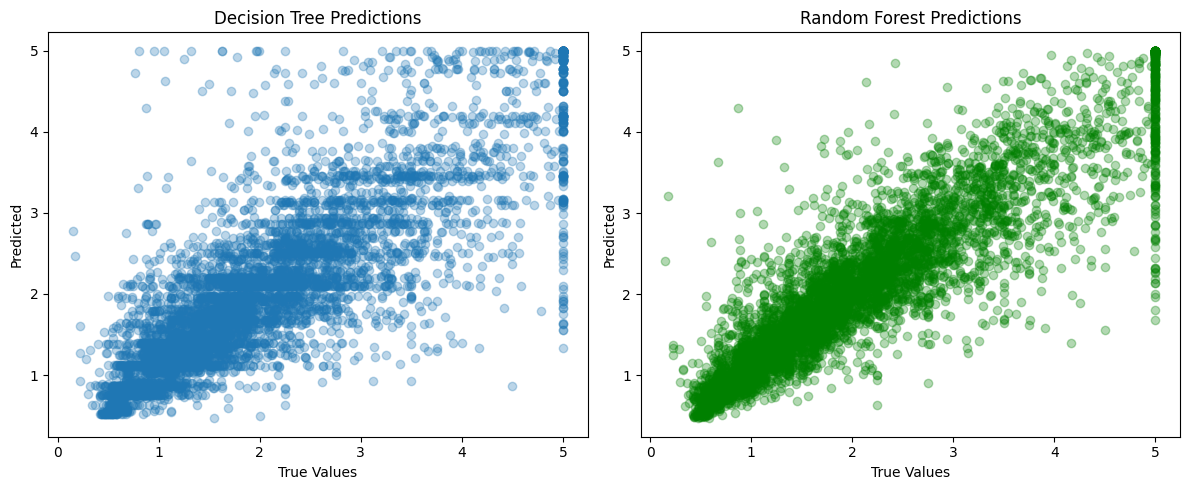

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_dt, alpha=0.3)
plt.title("Decision Tree Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='green')
plt.title("Random Forest Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

### Step 4: Visualize feature importances

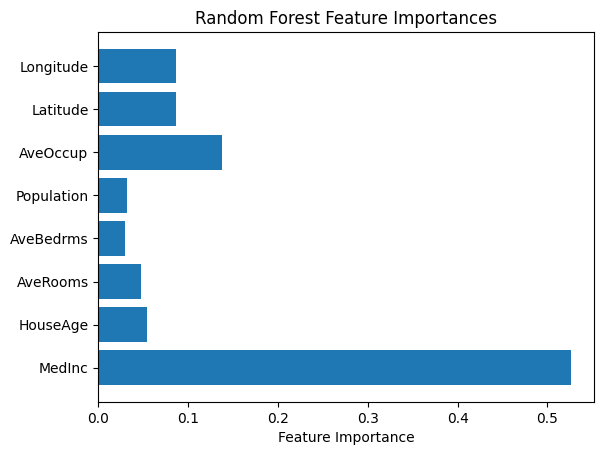

In [11]:
importances = rf.feature_importances_
plt.barh(housing.feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.show()